In [1]:
import keras
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import tensorflow as tf
from tensorflow import keras

Este jupytrer es para probar la funcion de la red que sintetiza el audio y ver que este todo en orden.

Lo que tiene que hacer es:

1.- 

In [42]:
def additive_synth(f0, loudness, harmonics):
    """
    f0:     (B, T, 1)
    loud:   (B, T, 1)
    harm:   (B, T, K)
    Devuelve: audio (B, N)
    """
    B = tf.shape(f0)[0]
    T = tf.shape(f0)[1]
    K = tf.shape(harmonics)[2]
    N = 64000
    sr = 16000
    # Upsampling a tasa de audio (ceil y recorte a N para evitar supuestos)
    reps = tf.cast(tf.math.ceil(tf.cast(N, tf.float32) / tf.cast(T, tf.float32)), tf.int32)
    f0_up   = tf.repeat(f0,   repeats=reps, axis=1)[:, :N, :]        # (B,N,1)
    loud_up = tf.repeat(loudness, repeats=reps, axis=1)[:, :N, :]    # (B,N,1)
    harm_up = tf.repeat(harmonics, repeats=reps, axis=1)[:, :N, :]   # (B,N,K)
    #noise_up = tf.repeat(noise, repeats=reps, axis=1)[:, :N, :]     # (B,N,65)
    # Fase acumulada: phi[n] = sum_{m<=n} 2*pi*f0[m]/fs
    omega = 2.0 * tf.constant(np.pi, tf.float32) * f0_up[..., 0] / float(sr)  # (B,N)
    phi = tf.cumsum(omega, axis=1)                                   # (B,N)
    phi = phi[:, :, tf.newaxis]                                      # (B,N,1)
    # Índices de armónicos k = 1..K
    ks = tf.reshape(tf.range(1, tf.cast(K, tf.int32) + 1, dtype=tf.float32), (1, 1, -1))  # (1,1,K)
    # Señal por armónico y suma final
    phase = phi * ks                             # (B,N,K)
    sig = loud_up * harm_up * tf.sin(phase)     # (B,N,K)
    audio_harm = tf.reduce_sum(sig, axis=-1)         # (B,N)
    
    return audio_harm

# Resample de audio y guardar

In [4]:
import scipy.io.wavfile as wav
import librosa
import soundfile as sf

fs, data = wav.read("Solo_DPA_10.wav")

print("frecuencia de muestreo: ", fs)
print("numero de muestras; ", len(data))
print("duracion: ", len(data)/fs, "segundos")
print("Data type:", data.dtype)

frecuencia de muestreo:  44100
numero de muestras;  2024341
duracion:  45.90342403628118 segundos
Data type: int16


La gracia de librosa es que al abrir el archivo lo convierte a float 32 y lo escala a [-1,1]

In [37]:
data, sr = librosa.load("Solo_DPA_10.wav", sr = 44100)

sr_new = 16000

audio_resampled = librosa.resample(data, orig_sr= sr, target_sr=sr_new)

print(len(audio_resampled))

sf.write("Solo_DPA_10_16000.wav", audio_resampled, sr_new)

734455


# Sacar el loudness

Esto es STFT -> |.|^2 ->  A-weighting -> log10 -> norm

(1025, 11476)
FFT por muestra:  1025
cantidad de ventanas de tiempo:  11476
(1025, 11476)


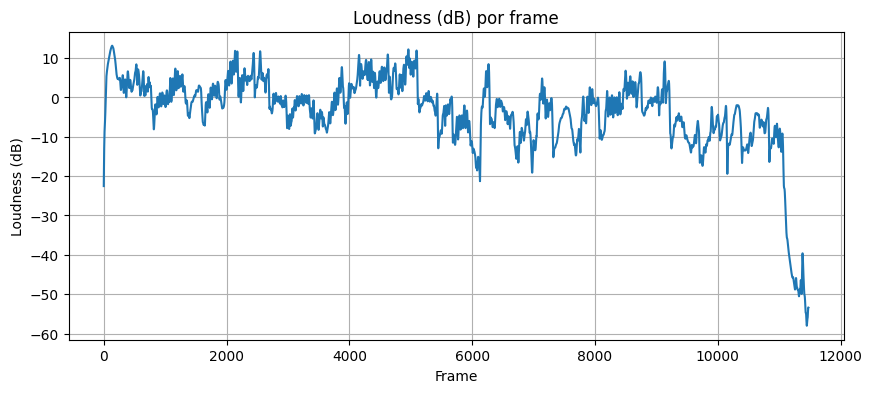

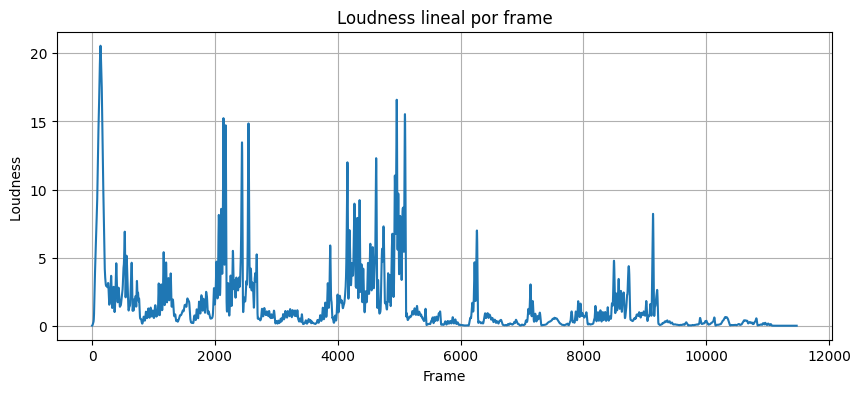

In [29]:
data, sr = librosa.load("Solo_DPA_10_16000.wav", sr = 16000)

n_fft = 2048
hop_length = 64

stft = librosa.core.stft(data, hop_length= hop_length, n_fft=n_fft)
potencia = np.abs(stft)**2
print(potencia.shape)
print("FFT por muestra: ", potencia.shape[0])
print("cantidad de ventanas de tiempo: ", potencia.shape[1])
freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

############# aca defino A-weighting ##################
def a_weighting(f):
    f = np.array(f)
    ra = (12200**2 * f**4) / (
        (f**2 + 20.6**2)
        * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2))
        * (f**2 + 12200**2)
    )
    A = 20 * np.log10(ra + 1e-12) + 2.0  # +2 dB para normalizar a 0 dB en 1 kHz
    return A
###########################################################
A_dB = a_weighting(freqs)
A_lin = 10 ** (A_dB / 20)

#aca aplico A-weighting 
power_A = potencia * A_lin[:, np.newaxis]
print(power_A.shape)



loudness_db = 10 * np.log10(np.mean(power_A, axis=0) + 1e-12)
loudness_db_norm = (loudness_db - np.mean(loudness_db))/np.std(loudness_db)

loudness_lin = np.mean(power_A, axis=0)

plt.figure(figsize=(10, 4))
plt.plot(loudness_db)
plt.title("Loudness (dB) por frame")
plt.xlabel("Frame")
plt.ylabel("Loudness (dB)")
plt.grid()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(loudness_lin)
plt.title("Loudness lineal por frame")
plt.xlabel("Frame")
plt.ylabel("Loudness ")
plt.grid()
plt.show()

# Sacar f_0 
esta parte es bien simple, todo la ventana y calculo el argmax

(11476,)
(11476,)


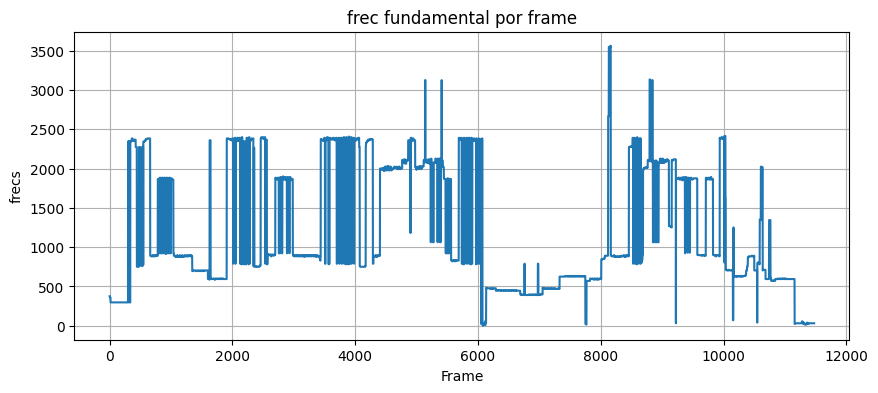

In [6]:
stft = np.abs(stft)

indices = np.argmax(stft, axis=0)
print(indices.shape)

f0_n = freqs[indices]

print(f0_n.shape)
plt.figure(figsize=(10, 4))
plt.plot(f0_n)
plt.title("frec fundamental por frame")
plt.xlabel("Frame")
plt.ylabel("frecs")
plt.grid()
plt.show()

11476


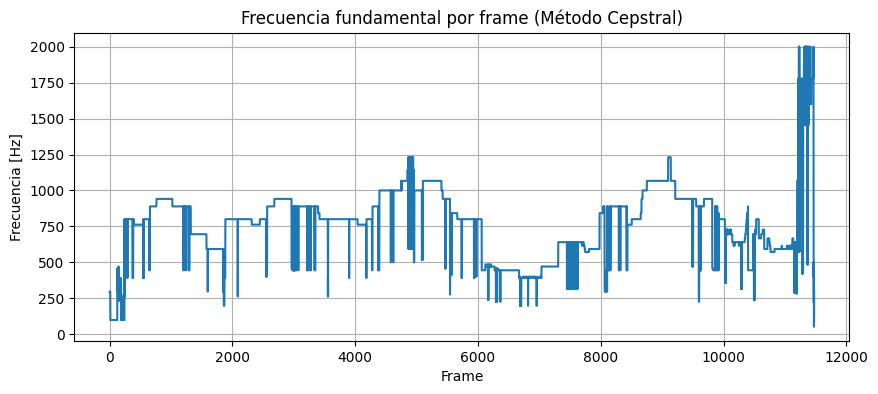

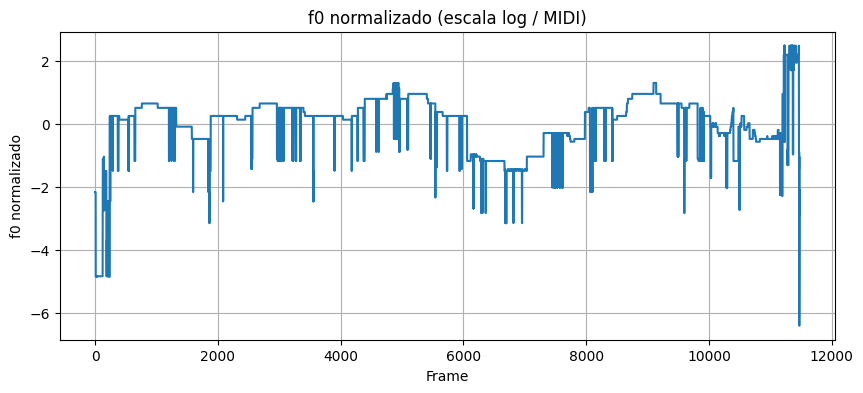

(11476,)


In [7]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

def f0_cepstrum(x, sr, frame_length=2048, hop_length=64, fmin=50, fmax=2000):
    """
    Estimación de f0 por método cepstral (por frames).
    """
    n_frames =  (len(x)) // hop_length +1
    print(n_frames)
    f0s = []

    for i in range(n_frames):
        start = i * hop_length
        frame = x[start:start + frame_length]
        #if len(frame) < frame_length:
        #    break

        # ventana Hamming
        frame = frame * np.hamming(len(frame))
        # FFT y magnitud logarítmica
        spectrum = np.fft.rfft(frame)
        log_mag = np.log(np.abs(spectrum) + 1e-10)

        # Cepstrum (FFT inversa del log espectro)
        cepstrum = np.fft.irfft(log_mag)

        # rango plausible de quefrencias (periodos)
        qmin = int(sr / fmax)
        qmax = int(sr / fmin)

        # buscar máximo en ese rango
        peak_index = np.argmax(cepstrum[qmin:qmax]) + qmin
        f0 = sr / peak_index
        f0s.append(f0)

    return np.array(f0s)

# === Uso ===
data, sr = librosa.load("Solo_DPA_10_16000.wav", sr=16000)
f0_n = f0_cepstrum(data, sr)

# === Normalización tipo DDSP (opcional) ===
f0_midi = 69 + 12 * np.log2(f0_n / 440.0)
f0_norm = (f0_midi - np.mean(f0_midi)) / np.std(f0_midi)

# === Gráficos ===
plt.figure(figsize=(10,4))
plt.plot(f0_n)
plt.title("Frecuencia fundamental por frame (Método Cepstral)")
plt.xlabel("Frame")
plt.ylabel("Frecuencia [Hz]")
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(f0_norm)
plt.title("f0 normalizado (escala log / MIDI)")
plt.xlabel("Frame")
plt.ylabel("f0 normalizado")
plt.grid()
plt.show()

print(f0_norm.shape)

Ahora voy a generar armonicos con decaimiento exponencial

In [16]:
B, T, K = 1, f0_n.shape[0], 101
ks = np.arange(1, K + 1)[np.newaxis, np.newaxis, :]  # (1,1,K)
# decaimiento armónico ~ 1/k
harmonics = (1.0 / ks) * np.random.uniform(0.8, 1.2, (B, T, K))
harmonics = harmonics / np.sum(harmonics, axis=-1, keepdims=True)  # normalizar energía
harmonics = harmonics.astype(np.float32)

print(harmonics.shape)
print(harmonics[0][1])

(1, 11476, 101)
[0.19862095 0.10586355 0.06227893 0.04879595 0.04194173 0.02701799
 0.03078426 0.02084137 0.01850982 0.02023471 0.0165539  0.01321934
 0.01566499 0.01207763 0.01391088 0.01270539 0.01317025 0.01046884
 0.01111093 0.0101492  0.0091165  0.00705831 0.0087734  0.0078581
 0.0070034  0.00842639 0.00653068 0.00794302 0.00715602 0.00549988
 0.005831   0.00492413 0.00588343 0.00531242 0.00479658 0.00502289
 0.0059623  0.00490334 0.00448518 0.0043599  0.00397947 0.00454239
 0.00358278 0.00475922 0.0035554  0.00456958 0.00412869 0.00466133
 0.00341238 0.0032337  0.00410272 0.00369155 0.00355136 0.00336369
 0.0032832  0.00403109 0.00273026 0.00273308 0.00265834 0.00273811
 0.0028722  0.00286184 0.00290971 0.00303877 0.00348339 0.00231993
 0.00275511 0.00245341 0.00302946 0.00252373 0.00220388 0.00225543
 0.0029655  0.00215305 0.00270477 0.00242331 0.00259035 0.00223162
 0.00192544 0.00249149 0.00187361 0.00268239 0.00245783 0.00222663
 0.00181397 0.00247348 0.00258008 0.00207854 0.

In [33]:
f0_tf   = tf.constant(f0_n, dtype=tf.float32)
loud_tf = tf.constant(loudness_lin, dtype=tf.float32)
harm_tf = tf.constant(harmonics, dtype=tf.float32)

f0_tf = tf.expand_dims(f0_tf, 0)
f0_tf = tf.expand_dims(f0_tf, -1)
loud_tf = tf.expand_dims(loud_tf, 0)
loud_tf = tf.expand_dims(loud_tf, -1)


print(f0_tf.shape)     # (1, 250, 1)
print(loud_tf.shape)   # (1, 250, 1)
print(harm_tf.shape)   # (1, 250, 101)


(1, 11476, 1)
(1, 11476, 1)
(1, 11476, 101)


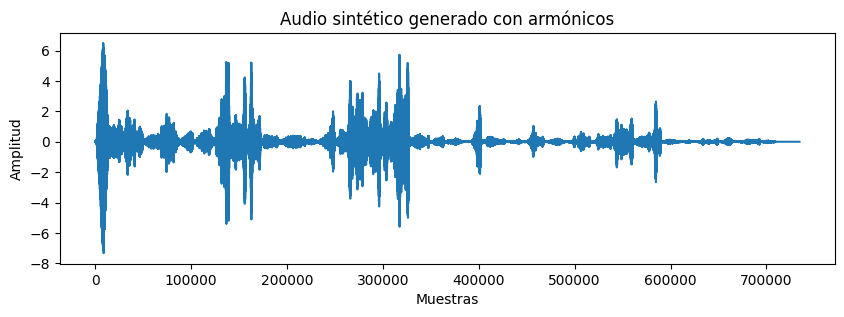

In [39]:
audio = additive_synth(f0_tf, loud_tf, harm_tf)

# Convertir a numpy y graficar
audio_np = audio.numpy()[0]
plt.figure(figsize=(10,3))
plt.plot(audio_np)
plt.title("Audio sintético generado con armónicos")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()

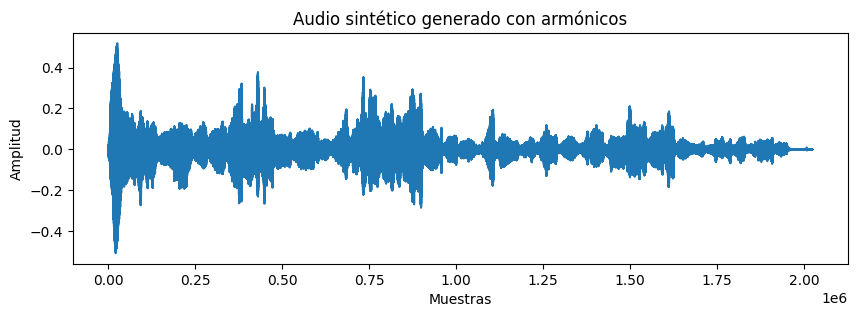

In [41]:
plt.figure(figsize=(10,3))
plt.plot(data)
plt.title("Audio sintético generado con armónicos")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()

In [40]:
import soundfile as sf
sf.write("test_ddsp.wav", audio_np, 16000)

Ahora lo voy a probar con batches de 250 cada uno

In [43]:
def split_into_blocks(x, block_size=250):
    """
    Divide un tensor (1, T, D) en bloques de longitud block_size.
    Retorna tensor (num_blocks, block_size, D)
    """
    B, T, D = x.shape
    num_blocks = T // block_size  # bloques completos
    x = x[:, :num_blocks * block_size, :]  # recorte exacto múltiplo de block_size
    x_blocks = tf.reshape(x, (num_blocks, block_size, D))
    return x_blocks

# Aplicamos a tus tensores
f0_blocks   = split_into_blocks(f0_tf, 250)
loud_blocks = split_into_blocks(loud_tf, 250)
harm_blocks = split_into_blocks(harm_tf, 250)

print(f0_blocks.shape)   # (45, 250, 1)
print(loud_blocks.shape) # (45, 250, 1)
print(harm_blocks.shape) # (45, 250, 101)


(45, 250, 1)
(45, 250, 1)
(45, 250, 101)


In [44]:
audio_Batched = additive_synth(f0_blocks, loud_blocks, harm_blocks)

print(audio_Batched.shape)

(45, 64000)


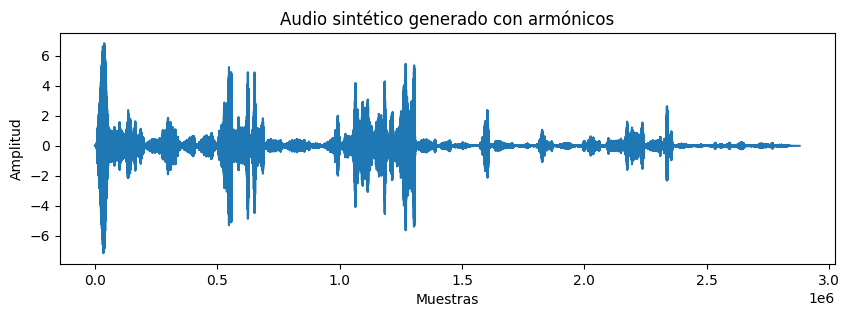

In [45]:
audios = []

for i in range(f0_blocks.shape[0]):
    audio_block = additive_synth(f0_blocks[i:i+1],
                                 loud_blocks[i:i+1],
                                 harm_blocks[i:i+1])
    audios.append(audio_block)

audio_full = tf.concat(audios, axis=1)  
audio_np = audio_full.numpy()[0]       

plt.figure(figsize=(10,3))
plt.plot(audio_np)
plt.title("Audio sintético generado con armónicos")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()